In [1]:
#Test dataloader
import ROOT
%pip install uproot
import spine
import larcv
import sys
sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/utils')
#import train_sheep_cnn_nersc.utils
from parse_yaml import ParseYAML
from data_loader import get_data_loader
import argparse
import os
import numpy as np
sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/spine/src/')
import spine, os, pkgutil
print('spine.__file__=', spine.__file__)
print('spine contents=', os.listdir(os.path.dirname(spine.__file__)))
print('walk_packages:', [m.name for m in pkgutil.walk_packages(spine.__path__)])


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
spine.__file__= /global/homes/e/ehinkle/.local/perlmutter/python-3.13/26.1.0/lib/python3.10/site-packages/spine/__init__.py
spine contents= ['calib', 'vis', 'bin', 'post', 'geo', '__init__.py', 'utils', 'main.py', 'banner.py', 'config', 'math', 'version.py', 'io', 'model', 'constants', 'data', '__pycache__', 'construct', 'ana', 'driver.py']
walk_packages: ['ana', 'banner', 'bin', 'calib', 'config', 'constants', 'construct', 'data', 'driver', 'geo', 'io', 'main', 'math', 'model', 'post', 'utils', 'version', 'vis']


In [2]:
os.chdir('/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/')

yaml_config='./configs/NDLAr_sheep.yaml'
config="mse_lin"
results_dir="./outputs"
run_num = 'test_data_loader'
#ckpt_file = 'ckpt_epoch_0_iters_25_best.tar'
params = ParseYAML(os.path.abspath(yaml_config), config)

params['local_valid_batch_size'] = 10
params['num_data_workers'] = 4
params['test_path'] = '/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/NDLAR_ELECTRON_SAMPLES/LARCV/TEST/'

test_data_loader, test_sampler = get_data_loader(params, params['test_path'], False, train=False)


In [3]:
import csv 
def get_tested_data_from_csv(csv_file):

    idxs = []
    labels = []
    preds = []
    ve = []
    ve_frac = []
    mg_frac = []
    oob_frac = []
    start_position = []
    rotation_matrix = []
    with open(csv_file, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            #print(row)
            idxs.append(str(row['idx']))
            labels.append(float(row['label']))
            preds.append(float(row['prediction']))
            ve.append(float(row['visible_energy']))
            ve_frac.append(float(row['ve_frac']))
            mg_frac.append(float(row['mg_frac']))
            oob_frac.append(float(row['oob_frac']))
            start_position.append(str(row['start_position']))
            rotation_matrix.append(str(row['rotation_matrix']))

    #print(idxs)
    idxs = np.array([np.fromstring(i.strip('[]'), sep=' ') for i in idxs])
    #print(idxs)
    labels = np.array(labels)
    preds = np.array(preds)
    ve = np.array(ve)
    ve_frac = np.array(ve_frac)
    mg_frac = np.array(mg_frac)
    oob_frac = np.array(oob_frac)
    start_position = np.array([np.fromstring(s.strip('[]'), sep=' ') for s in start_position])
    rotation_matrix = np.array([
        np.fromstring(r.replace('\n', ' ').replace('[', '').replace(']', ''), sep=' ').reshape(3, 3)
        for r in rotation_matrix
    ])

    return idxs, labels, preds, ve, ve_frac, mg_frac, oob_frac, start_position, rotation_matrix

In [10]:
# Load info from file
csv_file = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/test_l1_log/L1LOSS-LogEnergyScale-50kSample-NDLArTest-500bs-Test4/logs/L1LOSS-LogEnergyScale-50kSample-NDLArTest-500bs-Test4_test_l1_log_ckpt_epoch_90_iters7280_NUElog.csv'
idxs, labels, preds, ve, ve_frac, mg_frac, oob_frac, start_position, rotation_matrix = get_tested_data_from_csv(csv_file)

# Get the item from the dataloader and set it to fixed augmentation mode
item = 4950
start_pos = start_position[item]
rot_mat = rotation_matrix[item]
label = labels[item]
pred = preds[item]

test_data_loader.dataset.set_visualization_augmentation(start_pos, rot_mat)
combined_data, true_KE_initial_tensor, ve_frac_tensor, mg_frac_tensor, oob_frac_tensor, start_pos_tensor, rot_mat_tensor, idx_tensor = test_data_loader.dataset.__getitem__(item)
all_transformed = test_data_loader.dataset._last_fixed_aug_transformed_segments
all_energy = test_data_loader.dataset._last_fixed_aug_all_energy_points.flatten()
visible_points_mask = test_data_loader.dataset._last_fixed_aug_visible_points_mask
visible_points = all_transformed[visible_points_mask]
visible_energy = all_energy[visible_points_mask].flatten()

In [11]:
#print("Start position:", start_pos_tensor)
#print("Rotation matrix:", rot_mat_tensor)
#print("Visible energy fraction:", ve_frac_tensor)
print("Visible energy:", visible_energy[:5])
print("Visible energy shape:", visible_energy.shape)
#print("Visible points:", visible_points[20:40])
print("Visible points shape:", visible_points.shape)
print("Combined data:", combined_data[:10])
print("Combined data shape:", combined_data.shape)

Visible energy: [0.04031837 0.01130357 0.06734443 0.44690305 0.02123363]
Visible energy shape: (24712,)
Visible points shape: (24712, 3)
Combined data: tensor([[0.0000e+00, 1.2800e+03, 3.1200e+02, 8.9300e+02, 4.5917e-01],
        [0.0000e+00, 1.2800e+03, 3.2000e+02, 9.3800e+02, 5.8774e-03],
        [0.0000e+00, 1.2800e+03, 3.2300e+02, 9.4900e+02, 6.0880e-02],
        [0.0000e+00, 1.2800e+03, 3.3300e+02, 1.1850e+03, 8.9672e-02],
        [0.0000e+00, 1.2800e+03, 3.4000e+02, 1.0010e+03, 5.8799e-04],
        [0.0000e+00, 1.2800e+03, 3.4100e+02, 1.0000e+03, 1.0115e-01],
        [0.0000e+00, 1.2800e+03, 3.4300e+02, 1.0890e+03, 3.4410e-01],
        [0.0000e+00, 1.2800e+03, 3.4400e+02, 1.0520e+03, 8.4411e-01],
        [0.0000e+00, 1.2800e+03, 3.4400e+02, 1.0530e+03, 1.2355e+00],
        [0.0000e+00, 1.2800e+03, 3.4500e+02, 1.0510e+03, 1.8378e+00]])
Combined data shape: torch.Size([23851, 5])


In [12]:
import plotly.graph_objects as go
import yaml
import numpy as np

# Load YAML config
with open('./configs/NDLAr_sheep.yaml', 'r') as f:
    config = yaml.safe_load(f)

regions = config['default']['detector_active_regions']

fig = go.Figure()

# Color palette
colors = [
    'red', 'green', 'blue', 'yellow', 'magenta', 'cyan',
    'orange', 'purple', 'teal', 'pink', 'brown', 'gray',
]

for idx, region in enumerate(regions):
    min_corner = np.array(region[0])
    max_corner = np.array(region[1])
    
    # 8 vertices of the box
    vertices = np.array([
        min_corner,
        [max_corner[0], min_corner[1], min_corner[2]],
        [max_corner[0], max_corner[1], min_corner[2]],
        [min_corner[0], max_corner[1], min_corner[2]],
        [min_corner[0], min_corner[1], max_corner[2]],
        [max_corner[0], min_corner[1], max_corner[2]],
        max_corner,
        [min_corner[0], max_corner[1], max_corner[2]],
    ])
    
    # 12 edges
    edges = [
        (0, 1), (1, 2), (2, 3), (3, 0),  # bottom
        (4, 5), (5, 6), (6, 7), (7, 4),  # top
        (0, 4), (1, 5), (2, 6), (3, 7),  # vertical
    ]
    
    color = 'blue'  #colors[idx % len(colors)]
    
    for v1, v2 in edges:
        p1, p2 = vertices[v1], vertices[v2]
        fig.add_trace(go.Scatter3d(
            showlegend=False,
            x=[p1[2], p2[2]],
            y=[p1[0], p2[0]],
            z=[p1[1], p2[1]],
            mode='lines',
            line=dict(color=color, width=2),
            hoverinfo='skip'
        ))
# all transformed points
fig.add_trace(go.Scatter3d(
    x=all_transformed[:, 2],
    y=all_transformed[:, 0],
    z=all_transformed[:, 1],
    mode='markers',
    marker=dict(
        size=1,
        color=all_energy,
        colorscale='RdPu',
        showscale=False  # turn off colorbar for this trace
    ),
    name='All Energy Deposits',
))

# visible points
fig.add_trace(go.Scatter3d(
    x=visible_points[:, 2],
    y=visible_points[:, 0],
    z=visible_points[:, 1],
    mode='markers',
    marker=dict(
        size=1,
        color=visible_energy,  # values for color scale
        colorscale='Plasma_r',  # or 'Hot', 'Jet', 'Plasma', 'Inferno', etc.
        showscale=True,
        colorbar=dict(title='Energy (MeV)')
    ),
    name='Visible Energy Deposits',
))

fig.update_layout(
    showlegend=True,
    title=f'Shower Event Visualization (Label: {label:.2f}, Pred: {pred:.2f})',
    scene=dict(
        xaxis_title='Z (cm)',
        yaxis_title='X (cm)',
        zaxis_title='Y (cm)',
        aspectmode='data',
    ),
    width=1000,
    height=600,
)

fig.show()

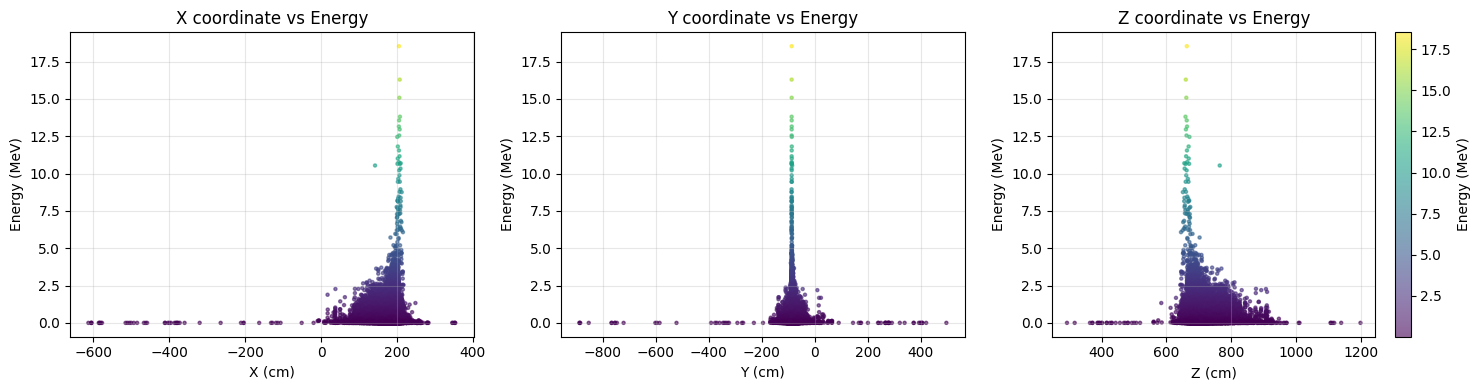

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# X vs Energy
axes[0].scatter(all_transformed[:, 0], all_energy, s=5, alpha=0.6, c=all_energy, cmap='viridis')
axes[0].set_xlabel('X (cm)')
axes[0].set_ylabel('Energy (MeV)')
axes[0].set_title('X coordinate vs Energy')
axes[0].grid(True, alpha=0.3)

# Y vs Energy
scatter2 = axes[1].scatter(all_transformed[:, 1], all_energy, s=5, alpha=0.6, c=all_energy, cmap='viridis')
axes[1].set_xlabel('Y (cm)')
axes[1].set_ylabel('Energy (MeV)')
axes[1].set_title('Y coordinate vs Energy')
axes[1].grid(True, alpha=0.3)

# Z vs Energy
axes[2].scatter(all_transformed[:, 2], all_energy, s=5, alpha=0.6, c=all_energy, cmap='viridis')
axes[2].set_xlabel('Z (cm)')
axes[2].set_ylabel('Energy (MeV)')
axes[2].set_title('Z coordinate vs Energy')
axes[2].grid(True, alpha=0.3)

fig.colorbar(scatter2, ax=axes[2], label='Energy (MeV)')
plt.tight_layout()
plt.show()

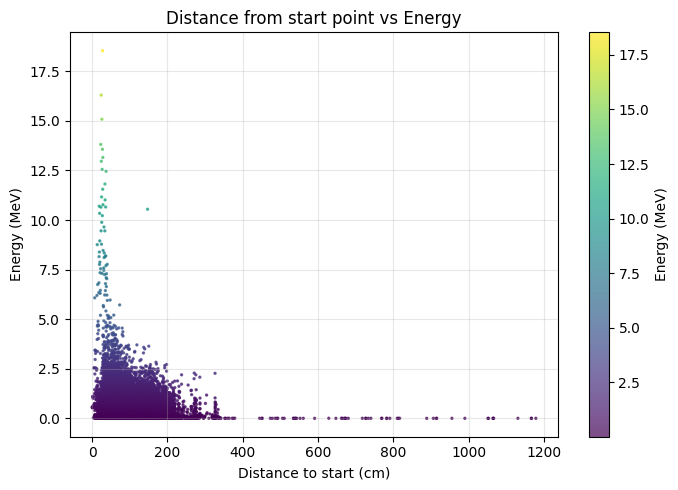

In [14]:
# Distance to start point vs Energy
# Ensure start_pos is a numpy array (start_pos is set earlier in the notebook)
start_np = np.asarray(start_pos)
# Compute Euclidean distances from each transformed point to the start position
distances = np.linalg.norm(all_transformed - start_np, axis=1)

plt.figure(figsize=(7, 5))
sc2 = plt.scatter(distances, all_energy, c=all_energy, cmap='viridis', s=2, alpha=0.7)
plt.colorbar(sc2, label='Energy (MeV)')
plt.xlabel('Distance to start (cm)')
plt.ylabel('Energy (MeV)')
plt.title('Distance from start point vs Energy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
'''for i, (inputs, targets, VE_frac, MG_frac, OOB_frac, start_pos, rot_mat, idx) in enumerate(test_data_loader):
    
    if i>0: break
    #print("Inputs shape:", inputs.shape)
    #print("Inputs initial entries:", inputs[:10])  # Check batch indices
    mask_first_event = inputs[:,0] == 0
    inputs_masked = inputs[mask_first_event]
    inputs_masked_x = np.array(inputs_masked[:, 1])
    inputs_masked_y = np.array(inputs_masked[:, 2])
    inputs_masked_z = np.array(inputs_masked[:, 3])
    inputs_masked_dE = np.array(inputs_masked[:, 4])
    #print("Target 0:", targets[0])
    start_pos_masked = start_pos[0]
    #print("Start position:", start_pos_masked)
    rot_mat_masked = rot_mat[0]
    #print("Rotation matrix:", rot_mat_masked)'''

'for i, (inputs, targets, VE_frac, MG_frac, OOB_frac, start_pos, rot_mat, idx) in enumerate(test_data_loader):\n    \n    if i>0: break\n    #print("Inputs shape:", inputs.shape)\n    #print("Inputs initial entries:", inputs[:10])  # Check batch indices\n    mask_first_event = inputs[:,0] == 0\n    inputs_masked = inputs[mask_first_event]\n    inputs_masked_x = np.array(inputs_masked[:, 1])\n    inputs_masked_y = np.array(inputs_masked[:, 2])\n    inputs_masked_z = np.array(inputs_masked[:, 3])\n    inputs_masked_dE = np.array(inputs_masked[:, 4])\n    #print("Target 0:", targets[0])\n    start_pos_masked = start_pos[0]\n    #print("Start position:", start_pos_masked)\n    rot_mat_masked = rot_mat[0]\n    #print("Rotation matrix:", rot_mat_masked)'

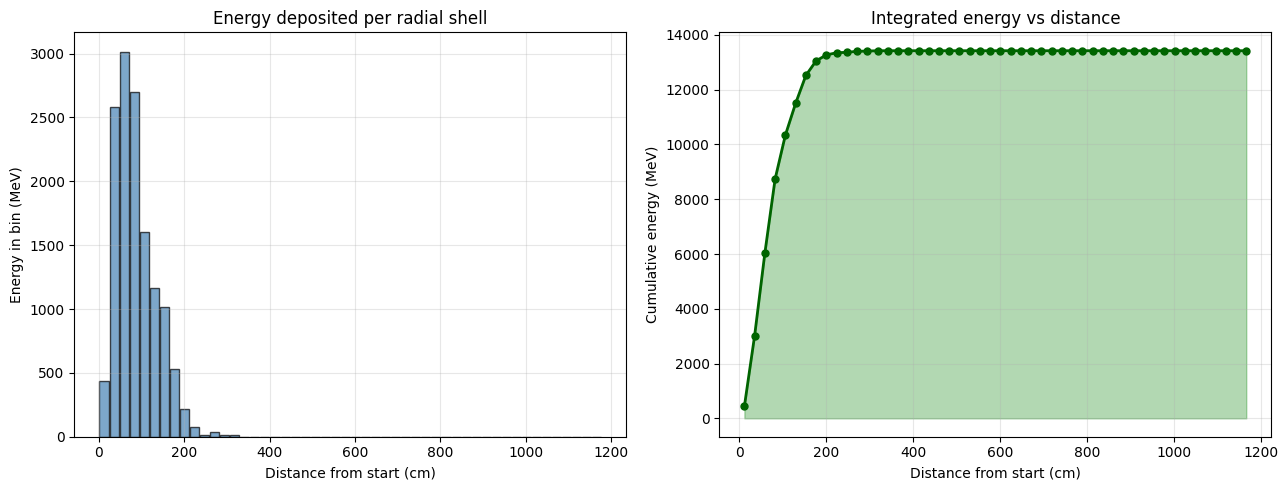

Total energy: 13423.48 MeV
Distance for 50% energy: 58.94 cm
Distance for 90% energy: 153.25 cm


In [16]:
import matplotlib.pyplot as plt

# Bin energy by distance from start point
n_bins = 50
dist_bins = np.linspace(distances.min(), distances.max(), n_bins + 1)
bin_centers = (dist_bins[:-1] + dist_bins[1:]) / 2
bin_width = dist_bins[1] - dist_bins[0]

# Sum energy in each bin
energy_per_bin = np.zeros(n_bins)
for i in range(n_bins):
    mask = (distances >= dist_bins[i]) & (distances < dist_bins[i+1])
    energy_per_bin[i] = np.sum(all_energy[mask])

# Cumulative energy (integrated from center outward)
cumulative_energy = np.cumsum(energy_per_bin)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Energy per bin vs distance
ax1.bar(bin_centers, energy_per_bin, width=bin_width*0.9, alpha=0.7, color='steelblue', edgecolor='black')
ax1.set_xlabel('Distance from start (cm)')
ax1.set_ylabel('Energy in bin (MeV)')
ax1.set_title('Energy deposited per radial shell')
ax1.grid(True, alpha=0.3)

# Plot 2: Cumulative energy vs distance
ax2.plot(bin_centers, cumulative_energy, 'o-', linewidth=2, markersize=5, color='darkgreen')
ax2.fill_between(bin_centers, cumulative_energy, alpha=0.3, color='green')
ax2.set_xlabel('Distance from start (cm)')
ax2.set_ylabel('Cumulative energy (MeV)')
ax2.set_title('Integrated energy vs distance')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary stats
print(f"Total energy: {cumulative_energy[-1]:.2f} MeV")
print(f"Distance for 50% energy: {bin_centers[np.argmin(np.abs(cumulative_energy - cumulative_energy[-1]/2))]:.2f} cm")
print(f"Distance for 90% energy: {bin_centers[np.argmin(np.abs(cumulative_energy - cumulative_energy[-1]*0.9))]:.2f} cm")